# Actividad 5 – Recorte y filtro

**Objetivo**: usar ROI y desenfoque.

En esta actividad vamos a:
1. Cargar una imagen
2. Recortar una región central (ROI)
3. Aplicar desenfoque gaussiano
4. Detectar bordes con Canny
5. Guardar el resultado

## 1. Importar librerías necesarias

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Configurar matplotlib para mostrar imágenes en el notebook
%matplotlib inline

## 2. Cargar una imagen

Cambia la ruta por la ubicación de tu imagen. Puedes usar cualquier imagen (jpg, png, etc.)

✓ Imagen cargada correctamente


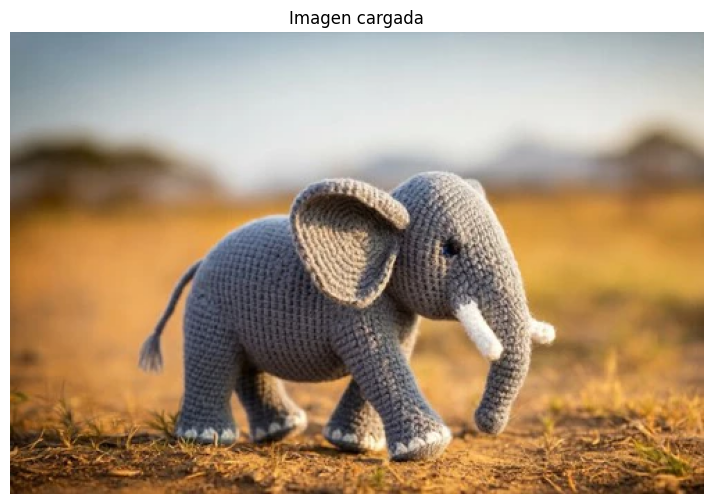

In [2]:
# Cargar la imagen
# Cambia 'imagen.jpg' por la ruta de tu imagen
imagen = cv2.imread('imagen.webp')

# Verificar que la imagen se cargó correctamente
if imagen is None:
    print("Error: No se pudo cargar la imagen. Verifica la ruta del archivo.")
else:
    print("✓ Imagen cargada correctamente")
    
    # Mostrar la imagen (convertir de BGR a RGB para matplotlib)
    imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 6))
    plt.imshow(imagen_rgb)
    plt.axis('off')
    plt.title('Imagen cargada')
    plt.show()

## 3. Recortar una región central (ROI)

ROI (Region of Interest) permite extraer una porción específica de la imagen.

RECORTE CENTRAL (ROI)
Imagen original:    500 x 333 píxeles
ROI recortada:      250 x 166 píxeles
Posición:           (125, 83)


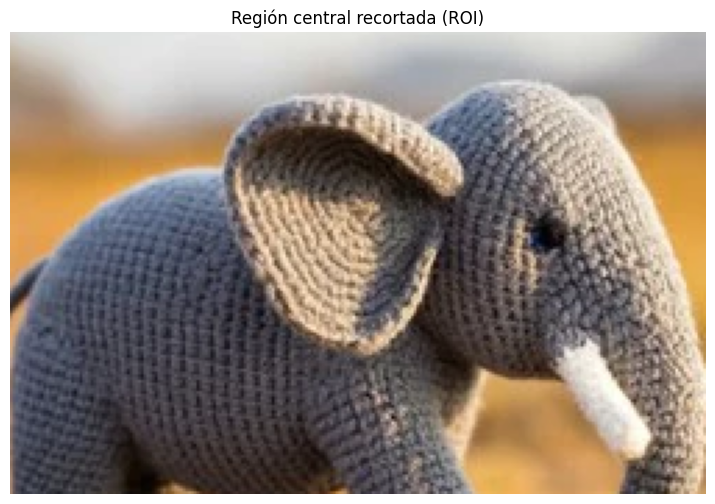

In [3]:
# Obtener dimensiones de la imagen
alto, ancho = imagen.shape[:2]

# Calcular coordenadas para un recorte central (50% del tamaño)
porcentaje_recorte = 0.5
nuevo_ancho = int(ancho * porcentaje_recorte)
nuevo_alto = int(alto * porcentaje_recorte)

# Calcular punto inicial para centrar el recorte
x_inicio = (ancho - nuevo_ancho) // 2
y_inicio = (alto - nuevo_alto) // 2

# Recortar la región de interés (ROI)
roi = imagen[y_inicio:y_inicio + nuevo_alto, x_inicio:x_inicio + nuevo_ancho]

print("=" * 50)
print("RECORTE CENTRAL (ROI)")
print("=" * 50)
print(f"Imagen original:    {ancho} x {alto} píxeles")
print(f"ROI recortada:      {nuevo_ancho} x {nuevo_alto} píxeles")
print(f"Posición:           ({x_inicio}, {y_inicio})")
print("=" * 50)

# Convertir ROI a RGB para visualización
roi_rgb = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(roi_rgb)
plt.title('Región central recortada (ROI)')
plt.axis('off')
plt.show()

## 4. Aplicar desenfoque gaussiano

El desenfoque gaussiano suaviza la imagen reduciendo el ruido y detalles.

✓ Desenfoque gaussiano aplicado con kernel (5, 5)


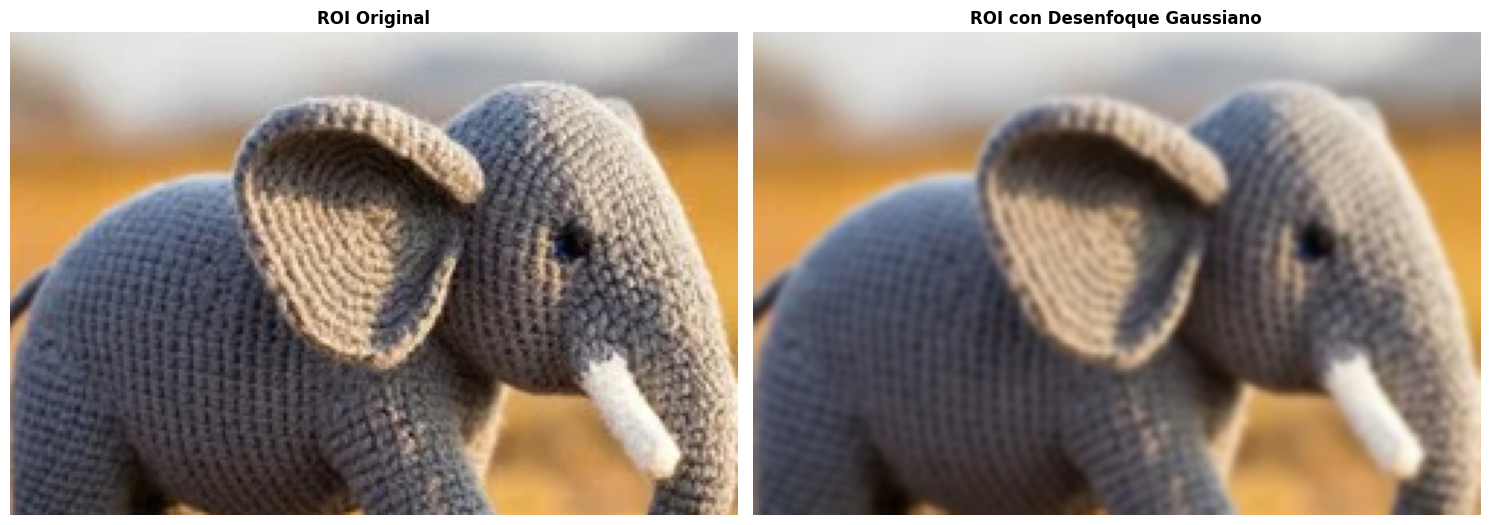

In [4]:
# Aplicar desenfoque gaussiano al ROI
# Parámetros: imagen, tamaño del kernel (debe ser impar), desviación estándar
kernel_size = (5, 5)
roi_blur = cv2.GaussianBlur(roi, kernel_size, 0)

print(f"✓ Desenfoque gaussiano aplicado con kernel {kernel_size}")

# Convertir a RGB para visualización
roi_blur_rgb = cv2.cvtColor(roi_blur, cv2.COLOR_BGR2RGB)

# Mostrar comparación
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].imshow(roi_rgb)
axes[0].set_title('ROI Original', fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(roi_blur_rgb)
axes[1].set_title('ROI con Desenfoque Gaussiano', fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 5. Detectar bordes con Canny

El algoritmo de Canny detecta bordes en la imagen basándose en gradientes de intensidad.

✓ Detección de bordes Canny aplicada
  Umbral mínimo: 50
  Umbral máximo: 150


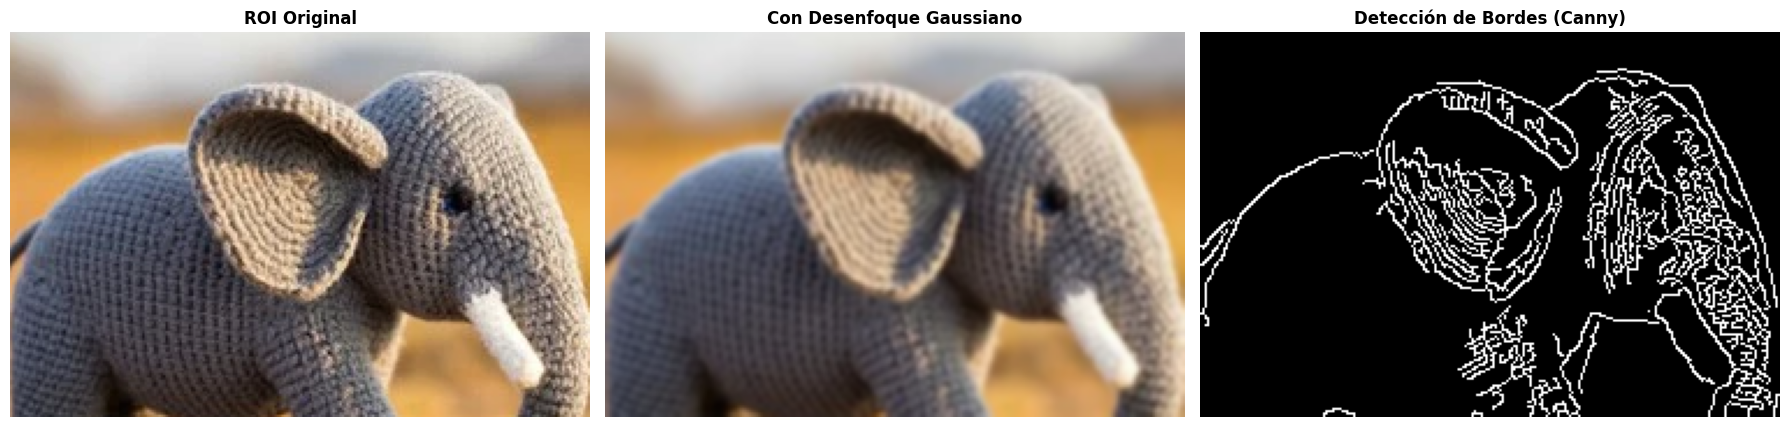

In [5]:
# Convertir a escala de grises (necesario para Canny)
roi_gris = cv2.cvtColor(roi_blur, cv2.COLOR_BGR2GRAY)

# Aplicar detector de bordes Canny
# Parámetros: imagen, umbral mínimo, umbral máximo
umbral_minimo = 50
umbral_maximo = 150
bordes = cv2.Canny(roi_gris, umbral_minimo, umbral_maximo)

print(f"✓ Detección de bordes Canny aplicada")
print(f"  Umbral mínimo: {umbral_minimo}")
print(f"  Umbral máximo: {umbral_maximo}")

# Mostrar las tres versiones
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(roi_rgb)
axes[0].set_title('ROI Original', fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(roi_blur_rgb)
axes[1].set_title('Con Desenfoque Gaussiano', fontsize=12, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(bordes, cmap='gray')
axes[2].set_title('Detección de Bordes (Canny)', fontsize=12, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## 6. Guardar el resultado

In [6]:
# Guardar la imagen con los bordes detectados
nombre_resultado = 'imagen_bordes_canny.jpg'
resultado = cv2.imwrite(nombre_resultado, bordes)

if resultado:
    print(f"✓ Imagen con bordes guardada como: {nombre_resultado}")
else:
    print(f"✗ Error al guardar la imagen")

✓ Imagen con bordes guardada como: imagen_bordes_canny.jpg
